In [1]:
!pip install -r requirements.txt

In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import city2graph as c2g
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import folium

/Users/alexchiric/Documents/Projects/City Maps/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
place = "Berceni, Bucuresti, Romania"

g = ox.geocode_to_gdf(place)
print(g.geom_type.iloc[0], "—", g.iloc[0]["display_name"])
print(g.drop(columns="geometry"))   # inspect attributes without the giant WKT blob

g.explore()     

Polygon — Berceni, Sector 4, Bucharest, Romania
   bbox_west  bbox_south  bbox_east  bbox_north  place_id osm_type     osm_id  \
0  26.097218   44.375814  26.139894   44.402836  60873615      way  240558380   

         lat        lon  class    type  place_rank  importance addresstype  \
0  44.388696  26.118004  place  suburb          19    0.388679      suburb   

      name                           display_name  
0  Berceni  Berceni, Sector 4, Bucharest, Romania  


In [ ]:


tag_groups = {
    "education": {"amenity": ["school", "kindergarten", "university", "college", "library"]},
    "health":    {"amenity": ["hospital", "clinic", "pharmacy", "doctors"], "healthcare": True},
    "green":     {"leisure": ["park", "playground", "garden", "sports_centre", "fitness_centre"]},
    "groceries": {"shop": ["supermarket", "convenience", "bakery", "greengrocer"],
                  "amenity": ["marketplace"]},
    "transit":   {"railway": ["station", "subway_entrance", "tram_stop"], "highway": ["bus_stop"]},
    "culture":   {"amenity": ["cafe", "restaurant", "bar", "cinema", "theatre"],
                  "tourism": ["museum", "gallery"]},
    "services":  {"amenity": ["bank", "atm", "post_office"]}
}

area = ox.geocode_to_gdf(place).geometry.iloc[0]d

def fetch(cat, tags):
    g = ox.features_from_polygon(area, tags=tags)
    g["poi_category"] = cat
    return g.to_crs(4326)

frames = []
with ThreadPoolExecutor(max_workers=3) as ex:                 
    futures = {ex.submit(fetch, c, t): c for c, t in tag_groups.items()}
    for fut in as_completed(futures):
        cat = futures[fut]
        try:
            frames.append(fut.result())
        except Exception as e:                                
            print(f"{cat} failed: {e}")                       

pois = gpd.GeoDataFrame(pd.concat(frames), crs=4326)

display(pois)

geometry     leisure access  \
element id                                                          
node    629035385    POINT (26.11789 44.38382)  playground    NaN   
        2250348043   POINT (26.10386 44.38452)  playground    yes   
        2250348051   POINT (26.10885 44.38713)  playground    NaN   
        2250348057   POINT (26.10852 44.38713)  playground    NaN   
        2263259743   POINT (26.10591 44.38671)  playground    NaN   
...                                        ...         ...    ...   
        11936592250  POINT (26.10916 44.38785)         NaN    NaN   
        12202542606  POINT (26.10891 44.39732)         NaN    NaN   
        12313880724  POINT (26.12559 44.39171)         NaN    NaN   
        13564347932  POINT (26.11762 44.38856)         NaN    NaN   
        13564646911   POINT (26.1174 44.38821)         NaN    NaN   

                                                name source  addr:city  \
element id                                                               
node    629035385                                NaN    NaN        NaN   
        2250348043                               NaN    NaN        NaN   
        2250348051                               NaN    NaN        NaN   
        2250348057                               NaN    NaN        NaN   
        2263259743                               NaN    NaN        NaN   
...                                              ...    ...        ...   
        11936592250             Cargus punct livrare    NaN  București   
        12202542606                              BCR    NaN        NaN   
        12313880724                              DPD    NaN  București   
        13564347932  Nexent Bank - Sucursala Berceni    NaN  București   
        13564646911                              BCR    NaN        NaN   

                    surface             branch brand brand:wikidata  ...  \
element id                                                           ...   
node    629035385       NaN                NaN   NaN            NaN  ...   
        2250348043      NaN                NaN   NaN            NaN  ...   
        2250348051      NaN                NaN   NaN            NaN  ...   
        2250348057      NaN                NaN   NaN            NaN  ...   
        2263259743      NaN                NaN   NaN            NaN  ...   
...                     ...                ...   ...            ...  ...   
        11936592250     NaN                NaN   NaN            NaN  ...   
        12202542606     NaN                NaN   BCR        Q806149  ...   
        12313880724     NaN                NaN   DPD        Q541030  ...   
        13564347932     NaN                NaN   NaN            NaN  ...   
        13564646911     NaN  Alexandru Obregia   BCR        Q806149  ...   

                    operator:wikipedia            official_name is_in:country  \
element id                                                                      
node    629035385                  NaN                      NaN           NaN   
        2250348043                 NaN                      NaN           NaN   
        2250348051                 NaN                      NaN           NaN   
        2250348057                 NaN                      NaN           NaN   
        2263259743                 NaN                      NaN           NaN   
...                                ...                      ...           ...   
        11936592250                NaN                      NaN           NaN   
        12202542606                NaN  Banca Comercială Română           NaN   
        12313880724                NaN                      NaN           NaN   
        13564347932                NaN                      NaN           NaN   
        13564646911                NaN  Banca Comercială Română           NaN   

                    short_name brand:ro cash_in indoor official_name:en  \
element id                                                 

In [5]:
G_w = ox.graph_from_polygon(area, network_type="all")

In [6]:
street_nodes, street_edges = ox.graph_to_gdfs(G_w)

print(len(street_nodes), "intersections |", len(street_edges), "street segments")

3705 intersections | 8397 street segments


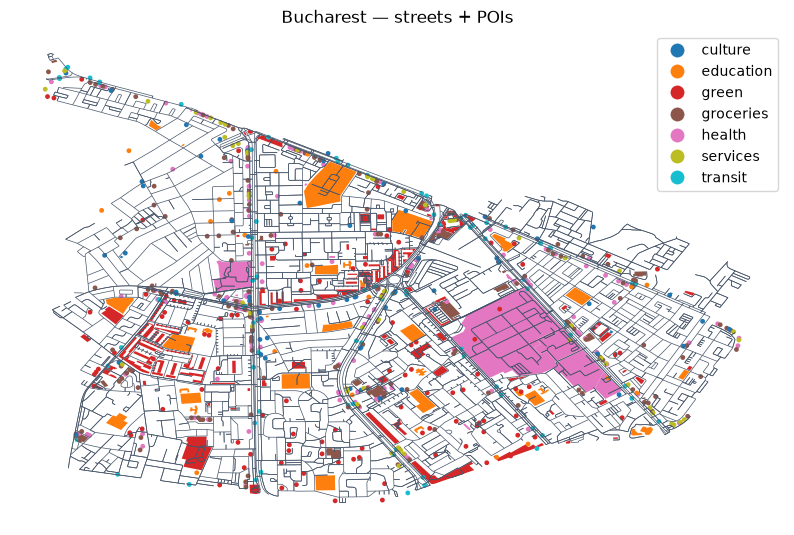

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

street_edges.plot(ax=ax, color="#475569", linewidth=0.5)       
#street_nodes.plot(ax=ax, color="#94a3b8", markersize=1)       
pois.plot(ax=ax, column="poi_category", markersize=6,           
          legend=True, cmap="tab10")

ax.set_axis_off()
ax.set_aspect("equal")
plt.title("Bucharest — streets + POIs")
fig.savefig("bucharest_map.svg", format="svg", bbox_inches="tight")
plt.show()

In [8]:
m = street_edges.explore(color="#475569", style_kwds={"weight": 1},
                         name="Streets", tiles="CartoDB positron")
pois.explore(m=m, column="poi_category", cmap="tab10",
             marker_kwds={"radius": 3},
             tooltip=["poi_category", "name"], name="POIs")
folium.LayerControl().add_to(m)

m.save("berceni_overlay.html")
